In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import os

In [7]:
df_u10_o = xr.open_dataset(r'/public1/dangw/data/location_all/xiamen_u10.nc')
df_v10_o = xr.open_dataset(r'/public1/dangw/data/location_all/xiamen_v10.nc')
df_sp_o  = xr.open_dataset(r'/public1/dangw/data/location_all/xiamen_sp.nc')
df_msl_o  = xr.open_dataset(r'/public1/dangw/data/location_all/xiamen_msl.nc')

def D3_standardscaler_u10(df1):
    num1 = df1.values.shape[0]
    res1 = np.zeros((df1.values.shape[0],df1.values.shape[1],df1.values.shape[2]))
    Mean = df_u10_o['u10'].values.mean()
    Std = df_u10_o['u10'].values.std()
    for i in range(num1):
        res1[i,:,:] = (df1.values[i,:,:] - Mean) / Std
        pass
    return res1

def D3_standardscaler_v10(df1):
    num1 = df1.values.shape[0]
    res1 = np.zeros((df1.values.shape[0],df1.values.shape[1],df1.values.shape[2]))
    Mean = df_v10_o['v10'].values.mean()
    Std = df_v10_o['v10'].values.std()
    for i in range(num1):
        res1[i,:,:] = (df1.values[i,:,:] - Mean) / Std
        pass
    return res1

def D3_standardscaler_sp(df1):
    num1 = df1.values.shape[0]
    res1 = np.zeros((df1.values.shape[0],df1.values.shape[1],df1.values.shape[2]))
    Mean = df_sp_o['sp'].values.mean()
    Std = df_sp_o['sp'].values.std()
    for i in range(num1):
        res1[i,:,:] = (df1.values[i,:,:] - Mean) / Std
        pass
    return res1

def D3_standardscaler_msl(df1):
    num1 = df1.values.shape[0]
    res1 = np.zeros((df1.values.shape[0],df1.values.shape[1],df1.values.shape[2]))
    Mean = df_msl_o['msl'].values.mean()
    Std  = df_msl_o['msl'].values.std()
    for i in range(num1):
        res1[i,:,:] = (df1.values[i,:,:] - Mean) / Std
        pass
    return res1

def D3_normalized(df2):
    num2 = df2.shape[0]
    res2 = np.zeros((df2.shape[0],df2.shape[1],df2.shape[2]))
    Min = df2.values.min()
    Max = df2.values.max()
    Diff = Max - Min
    for i in range(num2):
        res2[i,:,:] = (df2[i,:,:].values - Min) / Diff
        pass
    return res2

loc_data = pd.read_csv(r'/home/dangw/data/stormlocation/xmsurge.csv',sep=',',header=None) 
loc_data.columns = ['year','month','day','hour','value']  
loc_data = loc_data.groupby(['year','month','day'])['value'].max()
loc_data = loc_data[list(range(1958,2011))].values

xiamen_u10 = df_u10_o['u10'].loc['1958-1-1':'2010-12-31']
xiamen_v10 = df_v10_o['v10'].loc['1958-1-1':'2010-12-31']
xiamen_sp  = df_sp_o['sp'].loc['1958-1-1':'2010-12-31']
xiamen_msl = df_msl_o['msl'].loc['1958-1-1':'2010-12-31']
xiamen_sp  = D3_standardscaler_sp(xiamen_sp)
xiamen_u10 = D3_standardscaler_u10(xiamen_u10)
xiamen_v10 = D3_standardscaler_v10(xiamen_v10)
xiamen_msl = D3_standardscaler_msl(xiamen_msl)

print(xiamen_u10.shape)
print(xiamen_v10.shape)
print(xiamen_sp.shape)
print(xiamen_msl.shape)
print(loc_data.shape)

(154864, 40, 40)


In [13]:
loc_data = pd.read_csv(r'/home/dangw/data/stormlocation/xmsurge.csv',sep=',',header=None)  
loc_data.columns = ['year','month','day','hour','value']   
loc_data = loc_data.groupby(['year','month','day'])['value'].max()
loc_data = loc_data[list(range(1958,2011))].values
loc_data

array([ 1, 43, 64, ...,  4, -1, 24])

In [5]:
df_u10_o['u10'].values

array([[[ -0.9976487 ,  -0.87796044,  -0.7491734 , ...,  -1.4204066 ,
          -1.6758809 ,  -1.8984587 ],
        [ -0.88845944,  -0.7953687 ,  -0.67708063, ...,  -1.5183966 ,
          -1.7738712 ,  -2.0286458 ],
        [ -0.7792704 ,  -0.68547964,  -0.5923891 , ...,  -1.6163869 ,
          -1.8725615 ,  -2.128036  ],
        ...,
        [ -6.420008  ,  -6.4158087 ,  -6.3549147 , ...,  -1.5729914 ,
          -1.5785906 ,  -1.6541831 ],
        [ -6.5732927 ,  -6.368213  ,  -6.3059196 , ...,  -2.0741413 ,
          -2.0790408 ,  -1.956553  ],
        [ -6.520798  ,  -6.3164186 ,  -6.1652336 , ...,  -2.2988188 ,
          -2.237225  ,  -2.1133375 ]],

       [[ -2.1238363 ,  -2.107738  ,  -2.1140373 , ...,  -2.5514936 ,
          -2.6585832 ,  -2.7404747 ],
        [ -2.1028385 ,  -2.0125475 ,  -1.9894497 , ...,  -2.6984792 ,
          -2.8055682 ,  -2.9119577 ],
        [ -2.0818405 ,  -1.9915495 ,  -1.9005587 , ...,  -2.8461642 ,
          -2.9532537 ,  -3.0603433 ],
        ...,


1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
(19182, 3, 160, 160)
19182
[[[[False False False ... False False False]
   [False False False ... False False False]
   [False False False ... False False False]
   ...
   [False False False ... False False False]
   [False False False ... False False False]
   [False False False ... False False False]]

  [[False False False ... False False False]
   [False False False ... False False False]
   [False False False ... False False False]
   ...
   [False False False ... False False False]
   [False False False ... False False False]
   [False False False ... False False False]]

  [[False False False ... False False False]
   [False False Fals

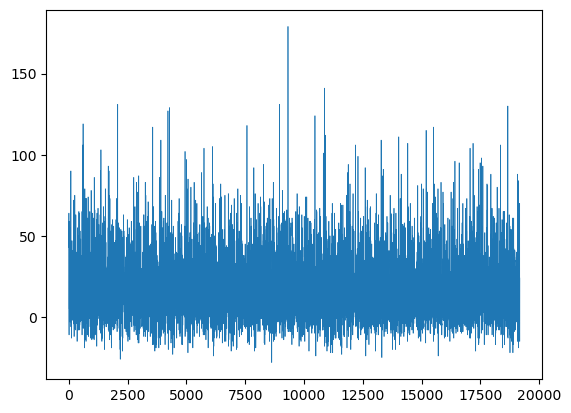

In [4]:
def array_reorganization(arrays):
    '''
    (16,40,40) == (1，1,160,160)
    '''
    array1 = np.concatenate((arrays[0],arrays[1],arrays[2],arrays[3]),axis=1)    
    array2 = np.concatenate((arrays[4],arrays[5],arrays[6],arrays[7]),axis=1)   
    array3 = np.concatenate((arrays[8],arrays[9],arrays[10],arrays[11]),axis=1) 
    array4 = np.concatenate((arrays[12],arrays[13],arrays[14],arrays[15]),axis=1)  
    res_array = np.concatenate((array1,array2,array3,array4),axis=0)  
    res_array = res_array.reshape(1,1,res_array.shape[0],res_array.shape[1]) 
    return res_array

def preprocess(cut_step):
    current_path = os.path.abspath('.')
    label = []
    pre_data = np.empty((0,3,160,160))   
    it = iter(range(loc_data.shape[0]))
    for index in it:
        if loc_data[index] == 9999:
            print('1')
            continue
        elif index <= (cut_step - 2) :   
            continue
        else:
            label.append(loc_data[index])
            aa = array_reorganization(xiamen_msl[(index-1)*8:(index+1)*8])  
            bb = array_reorganization(xiamen_u10[(index-1)*8:(index+1)*8])
            cc = array_reorganization(xiamen_v10[(index-1)*8:(index+1)*8])
            abc = np.concatenate((aa,bb,cc),axis=1)   
            pre_data = np.append(pre_data,abc,axis=0)   
        pass
    print(pre_data.shape)
    print(len(label))

    y = np.array(label)
    path_x = os.path.join(os.path.abspath('.'),'1958_2010x_uvm_xiamen_standardscaler.npy')
    path_y = os.path.join(os.path.abspath('.'),'1958_2010y_uvm_xiamen_orgin.npy')
    np.save(path_x,pre_data)
    np.save(path_y,y)
    print(np.isnan(pre_data))
    print(True in np.isnan(pre_data))
    print(np.isnan(pre_data).any(axis=0))

    plt.plot(range(len(label)),label,linewidth=0.5)
    plt.show()
    pass

if __name__ == '__main__':
    preprocess(2)

In [6]:
import numpy as np
# print(np.load('2000_2010x.npy').shape)
# print(np.load('2000_2010y.npy').shape)
fig1_data1 = np.load('1958_2010y_uvm_xiamen_orgin.npy')
fig1_data2 = np.load('1958_2010x_uvm_xiamen_standardscaler.npy')
print(fig1_data1.shape)
print(fig1_data2.shape)

(19182,)
(19182, 3, 160, 160)
